In [12]:
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [27]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer

from src.data.prepare_data import x_y_split, tt_split

In [14]:
np.random.seed(29)

In [15]:
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')

x, y = x_y_split(data)

# x_train, x_test, y_train, y_test = tt_split(x, y)

In [25]:
len(data)

126

In [19]:
sss = StratifiedShuffleSplit(
    n_splits=10, 
    test_size=0.2, 
    random_state=29
)

param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.01],
    'max_depth': [2, 3, 5],
    'min_child_weight': [2, 3, 5],
    'gamma': [0],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [0.1, 1],
    'colsample_bytree': [0.5, 0.6, 0.8],
    'subsample': [1]
}

In [21]:
counter = 1

for train_index, test_index in sss.split(x, y):
    print(counter)
    print(train_index.shape, test_index.shape)
    counter += 1

1
(100,) (26,)
2
(100,) (26,)
3
(100,) (26,)
4
(100,) (26,)
5
(100,) (26,)
6
(100,) (26,)
7
(100,) (26,)
8
(100,) (26,)
9
(100,) (26,)
10
(100,) (26,)


In [24]:
print(sss.split)

<bound method StratifiedShuffleSplit.split of StratifiedShuffleSplit(n_splits=10, random_state=29, test_size=0.2,
            train_size=None)>


In [16]:
n = 0

sss = StratifiedShuffleSplit(
    n_splits=10, 
    test_size=0.2, 
    random_state=29
)

param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.01],
    'max_depth': [2, 3, 5],
    'min_child_weight': [2, 3, 5],
    'gamma': [0],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [0.1, 1],
    'colsample_bytree': [0.5, 0.6, 0.8],
    'subsample': [1]
}

test_accuracies = []
cv_accuracies = []

for train_index, test_index in sss.split(x, y):
    x_train = x.iloc[train_index]
    x_test = x.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]
    
    xgb_grid = GridSearchCV(
        XGBClassifier(random_state=29),
        param_grid,
        cv=3, 
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    xgb_grid.fit(x_train, y_train)
    xgb_model = xgb_grid.best_estimator_

    y_pred = xgb_model.predict(x_test)

    test_accuracies.append(accuracy_score(y_test, y_pred))
    cv_accuracies.append(xgb_grid.best_score_)

    n += 1
    print(n)
    
    print('Best Parameters:')
    print(xgb_grid.best_params_)

print('Mean CV accuracy:')
print(round(np.mean(cv_accuracies), 3))

print('\nMean test accuracy:')
print(round(np.mean(test_accuracies), 3))

print('\nTest accuracy standard deviation:')
print(round(np.std(test_accuracies), 3))

print('\nIndividual test accuracies:')
print(np.round(test_accuracies, 3))

# display(Markdown('### XGB Classifier Report'))

# if best_threshold < 0.1 or best_threshold > 0.9:
#     display(Markdown('### ******BAD THRESHOLD******'))

# print('Best Parameters:')
# print(xgb_grid.best_params_)

# print("Best Threshold:", best_threshold)

# print('Training Data Accuracy:')
# print(round(threshold_model.score(x_train,y_train), 2))
# print('Testing Data Accuracy:')
# print(round(accuracy_score(y_test, y_pred), 2))

# print(classification_report(y_test, y_pred))

# display(Markdown('### Confusion Matrix'))

# ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
# plt.show()

# importance = pd.DataFrame({
#     'Feature': x_train.columns,
#     'Importance': xgb_model.feature_importances_.round(3)
# })

# importance = importance.sort_values('Importance', ascending=False)

# display(Markdown('### Feature Importance'))
# display(importance)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
1
Best Parameters:
{'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 1}
Fitting 3 folds for each of 108 candidates, totalling 324 fits
2
Best Parameters:
{'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 1}
Fitting 3 folds for each of 108 candidates, totalling 324 fits
3
Best Parameters:
{'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 1}
Fitting 3 folds for each of 108 candidates, totalling 324 fits
4
Best Parameters:
{'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 0

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}


### XGB Classifier Report

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}
Testing Data Accuracy:
0.46
              precision    recall  f1-score   support

           0       0.40      0.33      0.36        12
           1       0.50      0.57      0.53        14

    accuracy                           0.46        26
   macro avg       0.45      0.45      0.45        26
weighted avg       0.45      0.46      0.46        26



### Confusion Matrix

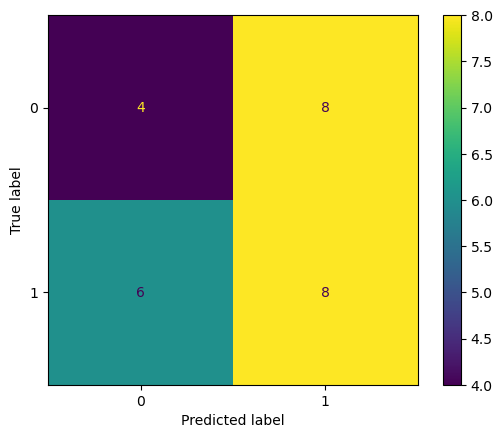

### Feature Importance

,Feature,Importance
0,X1,0.350
4,X5,0.159
5,X6,0.152
2,X3,0.142
3,X4,0.105
1,X2,0.092


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=29, stratify=y)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 5]
}
    
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=29),
    param_grid,
    cv=3, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)
xgb_model = xgb_grid.best_estimator_

y_pred = xgb_model.predict(x_test)

print('Best Parameters:')
print(xgb_grid.best_params_)

display(Markdown('### XGB Classifier Report'))

print('Best Parameters:')
print(xgb_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


### XGB Classifier Report

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Testing Data Accuracy:
0.81
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.80      0.86      0.83        14

    accuracy                           0.81        26
   macro avg       0.81      0.80      0.81        26
weighted avg       0.81      0.81      0.81        26



### Confusion Matrix

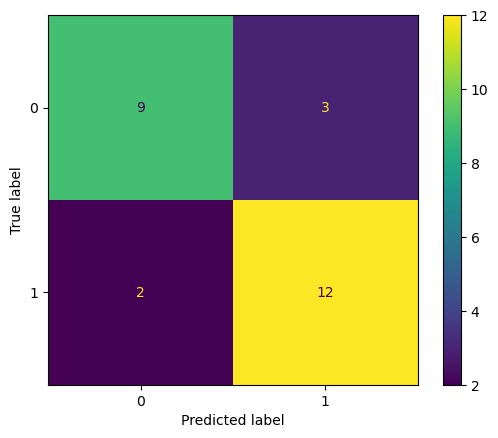

### Feature Importance

,Feature,Importance
0,X1,0.619
1,X5,0.381


In [49]:
x_drop = x.drop(columns=['X2', 'X3', 'X4', 'X6'])

x_train, x_test, y_train, y_test = train_test_split(x_drop, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5]
}
    
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(x_train, y_train)
xgb_model = xgb_grid.best_estimator_

y_pred = xgb_model.predict(x_test)

print('Best Parameters:')
print(xgb_grid.best_params_)

display(Markdown('### XGB Classifier Report'))

print('Best Parameters:')
print(xgb_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})

importance = importance.sort_values('Importance', ascending=False)

display(Markdown('### Feature Importance'))
display(importance)

### x_drop

In [17]:
x_drop = x.drop(columns=['X1'])

n = 0

sss = StratifiedShuffleSplit(
    n_splits=10, 
    test_size=0.2, 
    random_state=29
)

param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.01],
    'max_depth': [2, 3, 5],
    'min_child_weight': [2, 3, 5],
    'gamma': [0],
    'reg_alpha': [0.1, 1],
    'reg_lambda': [0.1, 1],
    'colsample_bytree': [0.5, 0.7, 1],
    'subsample': [1]
}

test_accuracies = []
cv_accuracies = []

for train_index, test_index in sss.split(x_drop, y):
    x_train = x_drop.iloc[train_index]
    x_test = x_drop.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]
    
    xgb_grid = GridSearchCV(
        XGBClassifier(random_state=29),
        param_grid,
        cv=3, 
        scoring='accuracy',
        n_jobs=-1,
        verbose=2
    )

    xgb_grid.fit(x_train, y_train)
    xgb_model = xgb_grid.best_estimator_

    y_pred = xgb_model.predict(x_test)

    test_accuracies.append(accuracy_score(y_test, y_pred))
    cv_accuracies.append(xgb_grid.best_score_)

    n += 1
    print(n)

print('Mean CV accuracy:')
print(round(np.mean(cv_accuracies), 3))

print('\nMean test accuracy:')
print(round(np.mean(test_accuracies), 3))

print('\nTest accuracy standard deviation:')
print(round(np.std(test_accuracies), 3))

print('\nIndividual test accuracies:')
print(np.round(test_accuracies, 3))

# display(Markdown('### XGB Classifier Report'))

# if best_threshold < 0.1 or best_threshold > 0.9:
#     display(Markdown('### ******BAD THRESHOLD******'))

# print('Best Parameters:')
# print(xgb_grid.best_params_)

# print("Best Threshold:", best_threshold)

# print('Training Data Accuracy:')
# print(round(threshold_model.score(x_train,y_train), 2))
# print('Testing Data Accuracy:')
# print(round(accuracy_score(y_test, y_pred), 2))

# print(classification_report(y_test, y_pred))

# display(Markdown('### Confusion Matrix'))

# ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
# plt.show()

# importance = pd.DataFrame({
#     'Feature': x_train.columns,
#     'Importance': xgb_model.feature_importances_.round(3)
# })

# importance = importance.sort_values('Importance', ascending=False)

# display(Markdown('### Feature Importance'))
# display(importance)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
1
Fitting 3 folds for each of 108 candidates, totalling 324 fits
2
Fitting 3 folds for each of 108 candidates, totalling 324 fits
3
Fitting 3 folds for each of 108 candidates, totalling 324 fits
4
Fitting 3 folds for each of 108 candidates, totalling 324 fits
5
Fitting 3 folds for each of 108 candidates, totalling 324 fits
6
Fitting 3 folds for each of 108 candidates, totalling 324 fits
7
Fitting 3 folds for each of 108 candidates, totalling 324 fits
8
Fitting 3 folds for each of 108 candidates, totalling 324 fits
9
Fitting 3 folds for each of 108 candidates, totalling 324 fits
10
Mean CV accuracy:
0.584

Mean test accuracy:
0.535

Test accuracy standard deviation:
0.04

Individual test accuracies:
[0.538 0.538 0.577 0.577 0.538 0.538 0.538 0.577 0.462 0.462]
